# A qubit-controlled cavity–cavity SWAP from $g1e0$ sidebands

Two cavities $a,b$ and one transmon, treated throughout as a **two-level system**
$\{|g\rangle,|e\rangle\}$.  A three-wave-mixing pump drives the $|g,1\rangle
\leftrightarrow|e,0\rangle$ sideband on each cavity.  From the *group commutator* of the
two sidebands we synthesize

$$H_{\rm hop}/\hbar=J\,\sigma^z\left(a^\dagger b+ab^\dagger\right),
\qquad \sigma^z=P_g-P_e,$$

Trotterize it, and combine it with one unconditional beamsplitter to make a
**controlled SWAP**: the two cavities exchange their states if and only if the transmon
is in $|e\rangle$.

Everything with loss is solved with the **exact Lindblad generator** — the channel of each
constant-$H$ pulse is $e^{\mathcal L\,\delta t}$, applied exactly.  No rate approximation,
no first-order expansion.  Section 5 checks this against `qutip.mesolve`.

## Results

**1. The commutator identity is exact.**  With $\sigma_+=|e\rangle\langle g|$,

$$i\left[\bar A_{\pi/2},\bar B_0\right]=\sigma^z\left(a^\dagger b+ab^\dagger\right),
\qquad\sigma^z=P_g-P_e,$$

to machine precision, where $\bar A_\phi=e^{i\phi}a\sigma_++e^{-i\phi}a^\dagger\sigma_-$.

**2. The controlled SWAP costs one extra beamsplitter.**  Since every $B(\theta)=e^{-i\theta
(a^\dagger b+ab^\dagger)}$ commutes with every other, a conditional angle $\theta$ plus an
unconditional angle $\varphi$ gives $B(\varphi+\theta)$ on $|g\rangle$ and
$B(\varphi-\theta)$ on $|e\rangle$.  Choosing $\varphi=-\theta=\pi/4$,

$$\boxed{\;B(\pi/4)\cdot e^{+i\frac{\pi}{4}\sigma^zX_{ab}}
=|g\rangle\langle g|\otimes\mathbb 1
\;+\;|e\rangle\langle e|\otimes(-i)^{\hat N}S\;}$$

— nothing on the $|g\rangle$ branch, a full SWAP on the $|e\rangle$ branch, carrying the
standard beamsplitter phase $(-i)^{\hat N}$ ($\hat N=n_a+n_b$), which is a *global* phase
inside each total-photon-number sector.  Verified exactly in section 3.

**3. There is a sharp optimum in the number of Trotter steps.**  Splitting $\pi/4$ into
$n$ steps, the coherent error falls as $n^{-2}$ (symmetrized sequence) while the total
duration — and hence the loss — grows as $\sqrt n$:

$$1-F\;\simeq\;\frac{\alpha}{n^{2}}\;+\;\beta\sqrt n .$$

**4. Photon loss, not Trotter error, is the wall.**  Exact average gate infidelity of the
controlled SWAP at its optimum, on the $d=2(N+1)$ logical sector with exactly $N$ photons
($T_1^{\rm cav}=300$ µs, $T_1^{\rm q}=200$ µs, $T_2^{\rm q}=150$ µs):

| photons $N$ | best $n$ | duration | $1-F_{\rm avg}$ | coherent part | loss part |
|---|---|---|---|---|---|
| 1 | 10 | 2.1 µs | **1.7 %** | 0.2 % | 1.5 % |
| 2 | 10 | 2.1 µs | **3.5 %** | 1.1 % | 2.5 % |
| 4 | 20 | 3.0 µs | **8.6 %** | 2.1 % | 6.5 % |
| 8 | 40 | 4.1 µs | **24 %** | 5.5 % | 19 % |

The synthesis is intrinsically slow — four pulses of area $\epsilon$ buy an angle
$\epsilon^2$ — so reaching $\pi/4$ takes microseconds, and at $N$ photons the cavities
decay $N$ times faster.  Cavity loss is the single largest contributor at every photon
number, about $5\times$ the cavity dephasing and the transmon terms.  The lever that helps
is a **larger $g$** (the duration scales as $1/g$ at fixed angle), not a better sequence.

**Part II** shows the same construction extended to a chain, where a second, purely
coherent obstruction appears.

## 1. Model, conventions, and the one approximation-free choice

| symbol | code | meaning |
|---|---|---|
| $a,b$ | `s.a`, `s.b` | cavity annihilation operators |
| $\sigma^\pm$ | — | $|e\rangle\langle g|$, $|g\rangle\langle e|$ |
| $\sigma^z$ | `s.sz` | $P_g-P_e$ (**+1 on the lower level**) |
| $X_{ab}$ | `s.X` | $a^\dagger b+ab^\dagger$ |
| $\hat N$ | — | $n_a+n_b$, total photon number |
| $A_\phi$ | `s.HA` | sideband $q\!\leftrightarrow\!a$, pump phase $\phi=\pi/2$ |
| $B_\psi$ | `s.HB` | sideband $q\!\leftrightarrow\!b$, pump phase $\psi=0$ |
| $\epsilon$ | `eps` | pulse area $g\tau$ of one sideband pulse |
| $n$ | `nsteps` | number of Trotter **steps** making up $\theta_{\rm tot}=-\pi/4$ |
| $n_{\rm pulse}$ | `NPULSE[name]` | sideband pulses **within one step**: 4 for $W$, 8 for $W_{\rm sym}$ |
| $f$ | `FACTOR[name]` | angle per step in units of $\epsilon^2$: $\theta_{\rm step}=-f\epsilon^2$ |

**Sign convention.**  $\sigma^z=P_g-P_e$ is the ordinary computational $\sigma^z$ with
$|0\rangle\equiv|g\rangle$.  It is also the convention that makes the commutator identity
come out with a $+$ sign.  Using $P_e-P_g$ instead just flips the sign of $\theta$,
i.e. shifts the relative pump phase by $\pi$.

**Basis.**  States $|q;n_a,n_b\rangle$ with $q+n_a+n_b\le n_{\rm log}+1$.  Every
Hamiltonian below conserves the total excitation $q+n_a+n_b$ and every jump operator
lowers it, so **with $n_{\rm th}=0$ this basis is exactly closed** — it is a symmetry
restriction, not a truncation, and there is no cutoff error to converge.  Setting
$n_{\rm th}=0$ is the one modelling choice made for convenience; at $n_{\rm th}=0.01$ the
extra infidelity is $\sim n_{\rm th}\kappa T\approx10^{-4}$ over a few µs, four orders
below what we find.

**Operators are built in the full space, then restricted once.**  Every operator is an
ordinary `qt.tensor` product on the *unrestricted* qubit $\otimes$ cavity $\otimes$ cavity
space, where a product such as $a^\dagger b$ is unambiguously correct, and is only then cut
down to the sector with `restrict`.  That is exact precisely because the sector is
invariant, and the notebook checks it directly: with $P$ the projector onto the sector,
$(\mathbb 1-P)\,O\,P=0$ for every $O$ the dynamics uses — the Hamiltonians, and every
collapse operator.  The residual is printed with the algebra checks below.

The restriction is what makes the open-system part affordable: at $n_{\rm log}=8$ it is
$D=100$ instead of $200$, and the Liouvillian has $D^2$ rows.  `restrict` also keeps the
operators **sparse**, which is the one performance-critical choice in the notebook:
`qt.liouvillian` inherits the storage type of its arguments, and a dense
$10^4\times10^4$ Liouvillian costs $33$ s to build against $10$ ms for the sparse one with
the same $43146$ nonzeros.


In [1]:
import itertools
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qutip as qt
import scipy.linalg as sla
import scipy.sparse as sps
from scipy.sparse.linalg import expm_multiply

pd.set_option("display.float_format", lambda v: f"{v:.4g}")

# ------------------------------------------------------------ device constants
T_SWAP = 0.200                    # us    full sideband swap  =>  g T_SWAP = pi/2
G = np.pi / (2 * T_SWAP)          # rad/us, sideband coupling  (g/2pi = 1.25 MHz)
G_BS = G                          # rad/us, native unconditional beamsplitter rate
T1_CAV, TPHI_CAV = 300.0, 1000.0  # us    cavity relaxation and pure dephasing
T1_QB, T2_QB = 200.0, 150.0       # us    transmon g-e relaxation and coherence

KAPPA, GPHI_CAV = 1 / T1_CAV, 1 / TPHI_CAV      # cavity rates
GAM_QB = 1 / T1_QB                              # transmon relaxation rate
GPHI_QB = 1 / T2_QB - 0.5 / T1_QB               # pure dephasing left after the T1 limit
assert GPHI_QB > 0

# ------------------------------------------------------------ small helpers
def mx(op):
    """Largest absolute matrix element of a Qobj or an array."""
    return float(np.max(np.abs(op.full() if isinstance(op, qt.Qobj) else op)))


def comm(P, Q):
    """[P,Q] = PQ - QP.  Uses @, so it is a matrix product for Qobjs and for arrays."""
    return P @ Q - Q @ P


def propagator(H, dt):
    """exp(-i H dt) as a plain array.  scipy's dense expm is ~10x faster than
    Qobj.expm() at these sizes, and every H here is a small dense matrix."""
    return sla.expm(-1j * H.full() * dt)


print(f"g/2pi = {G/(2*np.pi):.3f} MHz    full swap {T_SWAP*1e3:.0f} ns")
print(f"cavity: T1 = {T1_CAV:.0f} us, Tphi = {TPHI_CAV:.0f} us")
print(f"transmon: T1 = {T1_QB:.0f} us, T2 = {T2_QB:.0f} us "
      f"=> gamma_phi = {GPHI_QB:.5f}/us")

g/2pi = 1.250 MHz    full swap 200 ns
cavity: T1 = 300 us, Tphi = 1000 us
transmon: T1 = 200 us, T2 = 150 us => gamma_phi = 0.00417/us


## 2. The $g1e0$ sideband and the commutator identity

In the frame rotating with the pump, the resonant drive on cavity $a$ is

$$A_\phi = g\left(e^{i\phi}\,a\,\sigma_+ + e^{-i\phi}\,a^\dagger\sigma_-\right),
\qquad\sigma_+=|e\rangle\langle g| ,$$

and identically $B_\psi$ with $b$.  Writing $\bar A_\phi=A_\phi/g$ and expanding the
commutator — cavity operators of *different* modes commute, so each term factorizes into
(cavity)$\times$(spin):

$$[\bar A_\phi,\bar B_\psi]=
\underbrace{e^{i(\phi+\psi)}ab\,[\sigma_+,\sigma_+]}_{=0}
+e^{i(\phi-\psi)}ab^\dagger[\sigma_+,\sigma_-]
+e^{-i(\phi-\psi)}a^\dagger b\,[\sigma_-,\sigma_+]
+\underbrace{e^{-i(\phi+\psi)}a^\dagger b^\dagger[\sigma_-,\sigma_-]}_{=0}.$$

The outer two vanish because $\sigma_\pm^2=0$.  For the middle two,
$\sigma_+\sigma_-=P_e$ and $\sigma_-\sigma_+=P_g$, so
$[\sigma_-,\sigma_+]=P_g-P_e=\sigma^z$.  With the relative pump phase
$\delta=\phi-\psi$,

$$[\bar A_\phi,\bar B_\psi]=\sigma^z\left(e^{-i\delta}a^\dagger b-e^{i\delta}ab^\dagger\right)$$

and at $\delta=\pi/2$

$$\boxed{\;i\,[\bar A_{\pi/2},\bar B_0]=\sigma^z\left(a^\dagger b+ab^\dagger\right)
=\sigma^zX_{ab}\;}$$

The relative pump phase rotates the beamsplitter axis and does nothing else: at
$\delta=0$ one gets the orthogonal quadrature $i\sigma^z(a^\dagger b-ab^\dagger)$.

The **anticommutator** is worth writing down too, because it is what survives if the two
pulses commute through each other:

$$\{\bar A_0,\bar B_0\}=a^\dagger b+ab^\dagger$$

— *no* $\sigma^z$.  The conditionality of the gate comes entirely from the ordering of the
two native pulses.

In [2]:
def restrict(op, keep):
    """Restrict an operator to the subspace spanned by the basis states `keep`.

    Exact whenever that subspace is invariant, which is verified below.  Everything
    is therefore built with ordinary qutip tensor products in the FULL space -- where
    a product like a^dag b is unambiguously correct -- and only then restricted.

    The result is kept SPARSE, which is the one performance-critical choice in the
    notebook: qt.liouvillian propagates the storage type of its arguments, and a dense
    Liouvillian at D = 100 takes 33 s to build (10^4 x 10^4 entries) against 10 ms for
    the sparse one -- with identical nonzeros.
    """
    return qt.Qobj(sps.csr_matrix(op.full()[np.ix_(keep, keep)]))


class Link:
    """Qubit (g,e) + cavities a,b, restricted to total excitation q+na+nb <= n_log+1.

    Attributes are all qutip Qobj operators on the restricted space, so they can be
    handed straight to qt.liouvillian / qt.mesolve.
    """

    def __init__(self, n_log):
        self.n_log = n_log
        m_max = n_log + 1                     # highest total excitation kept
        nc = m_max + 1                        # Fock states per cavity: 0 .. m_max
        self.nc = nc

        # ---- full product space, standard qutip tensor products
        I2, Ic = qt.qeye(2), qt.qeye(nc)
        g, e = qt.basis(2, 0), qt.basis(2, 1)
        a = qt.tensor(I2, qt.destroy(nc), Ic)          # cavity a
        b = qt.tensor(I2, Ic, qt.destroy(nc))          # cavity b
        sm = qt.tensor(g * e.dag(), Ic, Ic)            # sigma_- = |g><e|
        Pg = qt.tensor(g * g.dag(), Ic, Ic)            # P_g
        Pe = qt.tensor(e * e.dag(), Ic, Ic)            # P_e

        # ---- the excitation-closed sector, and the map (q,na,nb) -> row index
        self.states, keep = [], []
        for q in (0, 1):                               # transmon: g = 0, e = 1
            for na in range(nc):                       # photons in a
                for nb in range(nc):                   # photons in b
                    if q + na + nb <= m_max:           # the closed sector
                        self.states.append((q, na, nb))
                        keep.append((q * nc + na) * nc + nb)   # index in the full space
        self.index = {st: i for i, st in enumerate(self.states)}
        self.D = len(keep)
        self.keep = keep

        # ---- the operators we need, restricted once
        # ---- every operator the dynamics uses, built in the full space
        full_ops = {"a": a, "b": b, "sigma_-": sm, "n_a": a.dag() * a,
                    "n_b": b.dag() * b, "P_e": Pe, "P_g": Pg,
                    "a sigma_+": a * sm.dag(), "b sigma_+": b * sm.dag(),
                    "a^dag b": a.dag() * b}

        # ---- the sector is invariant: none of these takes a kept state outside it,
        #      which is what makes `restrict` exact.  Q O P must vanish for every O.
        P = np.zeros(a.shape)                          # projector onto the sector
        P[keep, keep] = 1.0
        Q = np.eye(a.shape[0]) - P                     # projector onto everything else
        self.leakage = 0.0
        for name, op in full_ops.items():
            self.leakage = max(self.leakage, mx(Q @ op.full() @ P))

        # ---- the same operators, restricted once and for all
        self.a, self.b = restrict(a, keep), restrict(b, keep)
        self.sm, self.sp = restrict(sm, keep), restrict(sm.dag(), keep)
        self.Pg, self.Pe = restrict(Pg, keep), restrict(Pe, keep)
        self.sz = self.Pg - self.Pe                    # sigma^z = P_g - P_e
        self.na = restrict(full_ops["n_a"], keep)      # n_a
        self.nb = restrict(full_ops["n_b"], keep)      # n_b
        self.N = self.na + self.nb                     # total photon number
        self.ad_b = restrict(full_ops["a^dag b"], keep)          # a^dag b
        self.X = self.ad_b + self.ad_b.dag()           # X_ab = a^dag b + a b^dag
        self.a_sp = restrict(full_ops["a sigma_+"], keep)         # a sigma_+  (g1e0)
        self.b_sp = restrict(full_ops["b sigma_+"], keep)         # b sigma_+

        self.HA = G * self.A(np.pi / 2)                # A leg, pump phase pi/2
        self.HB = G * self.B(0.0)                      # B leg, pump phase 0
        self.HBS = G_BS * self.X                       # unconditional beamsplitter

        # ---- six local collapse operators
        self.c_ops = [np.sqrt(KAPPA) * self.a, np.sqrt(KAPPA) * self.b,
                      np.sqrt(2 * GPHI_CAV) * self.na, np.sqrt(2 * GPHI_CAV) * self.nb,
                      np.sqrt(GAM_QB) * self.sm, np.sqrt(2 * GPHI_QB) * self.Pe]
        self.c_names = ["cavity a loss", "cavity b loss", "cavity a dephasing",
                        "cavity b dephasing", "transmon decay", "transmon dephasing"]
        self._L = {}                                   # Liouvillian cache, filled later

    def A(self, phi):
        """A_phi / g = e^{i phi} a sigma_+ + h.c."""
        return np.exp(1j * phi) * self.a_sp + np.exp(-1j * phi) * self.a_sp.dag()

    def B(self, psi):
        """B_psi / g = e^{i psi} b sigma_+ + h.c."""
        return np.exp(1j * psi) * self.b_sp + np.exp(-1j * psi) * self.b_sp.dag()

    def ket(self, q, na, nb):
        """|q; na, nb> as a state vector on the restricted space."""
        v = np.zeros(self.D, dtype=complex)
        v[self.index[(q, na, nb)]] = 1.0
        return v


s = Link(n_log=2)
checks = {
    "operators leaking out of the sector (justifies `restrict`)": s.leakage,
    "i[A_pi/2, B_0] - sz X": mx(1j * comm(s.A(np.pi / 2), s.B(0)) - s.sz * s.X),
    "i[A_pi/2, B_0] + sz X   (MUST be large: fixes the sign)":
        mx(1j * comm(s.A(np.pi / 2), s.B(0)) + s.sz * s.X),
    "{A_0, B_0} - X   (the anticommutator carries no sz)":
        mx(s.A(0) * s.B(0) + s.B(0) * s.A(0) - s.X),
    "A(phi+pi) + A(phi)   (a sign flip is a pi pump-phase shift)":
        mx(s.A(0.7 + np.pi) + s.A(0.7)),
}
for delta in (0.0, 0.31, 1.17, -0.83):      # a general relative pump phase
    pred = s.sz * (np.exp(-1j * delta) * s.ad_b - np.exp(1j * delta) * s.ad_b.dag())
    checks[f"[A_d, B_0] - sz(e^-id a+b - e^id ab+),  delta = {delta:+.2f}"] = mx(
        comm(s.A(delta), s.B(0)) - pred)
display(pd.Series(checks, name="residual").to_frame())
assert max(v for k, v in checks.items() if "MUST" not in k) < 1e-12
assert checks["i[A_pi/2, B_0] + sz X   (MUST be large: fixes the sign)"] > 1e-3
print(f"D = {s.D} for n_log = {s.n_log}  (full product space would be "
      f"{2 * s.nc**2})")
print("The g1e0 identity holds exactly, with sigma^z = P_g - P_e.")

,residual
operators leaking out of the sector (justifies `restrict`),0
"i[A_pi/2, B_0] - sz X",0
"i[A_pi/2, B_0] + sz X (MUST be large: fixes the sign)",4
"{A_0, B_0} - X (the anticommutator carries no sz)",0
A(phi+pi) + A(phi) (a sign flip is a pi pump-phase shift),0
"[A_d, B_0] - sz(e^-id a+b - e^id ab+), delta = +0.00",0
"[A_d, B_0] - sz(e^-id a+b - e^id ab+), delta = +0.31",0
"[A_d, B_0] - sz(e^-id a+b - e^id ab+), delta = +1.17",0
"[A_d, B_0] - sz(e^-id a+b - e^id ab+), delta = -0.83",0


D = 16 for n_log = 2  (full product space would be 32)
The g1e0 identity holds exactly, with sigma^z = P_g - P_e.


## 3. From the $\sigma^z$ beamsplitter to a controlled SWAP

Write $B(\theta)=e^{-i\theta X_{ab}}$ for the ordinary beamsplitter.  All of these
commute with one another and with $\sigma^zX_{ab}$, so **angles simply add**.  A
conditional evolution $e^{-i\theta\,\sigma^zX_{ab}}$ acts as

$$|g\rangle:\;B(\theta),\qquad |e\rangle:\;B(-\theta),$$

so following it with an *unconditional* $B(\varphi)$ gives $B(\varphi+\theta)$ and
$B(\varphi-\theta)$.  To make one branch do nothing we need $\varphi=-\theta$, and then
the other branch gets $B(-2\theta)$.  A full swap is $B(\pi/2)$, so

$$\theta=-\tfrac\pi4,\qquad \varphi=+\tfrac\pi4 .$$

The Trotter sequences below produce $\theta=-f\epsilon^2<0$, which is exactly the sign we
need.  What is $B(\pi/2)$?  From $B^\dagger aB=a\cos\theta-ib\sin\theta$ at $\theta=\pi/2$
we get $a\mapsto-ib$, $b\mapsto-ia$, hence on Fock states

$$B(\pi/2)\,|n_a,n_b\rangle=(-i)^{n_a+n_b}\,|n_b,n_a\rangle,$$

a SWAP times $(-i)^{\hat N}$.  Since $\hat N$ is conserved by everything here, that factor
is a **global phase within each total-photon-number sector**; across sectors it is a
deterministic, known phase (removable, if wanted, by a dispersive $\sigma^z\hat N$
rotation).  The target is therefore

$$U_{\rm CSWAP}= |g\rangle\langle g|\otimes\mathbb 1
+|e\rangle\langle e|\otimes(-i)^{\hat N}S .$$

In [3]:
def mode_swap(s):
    """S |q; na, nb> = |q; nb, na>, as an explicit permutation."""
    S = np.zeros((s.D, s.D), dtype=complex)
    for (q, na, nb), col in s.index.items():          # every basis state
        S[s.index[(q, nb, na)], col] = 1.0            # send it to the swapped one
    return qt.Qobj(S)


def beamsplitter(s, theta):
    """B(theta) = exp(-i theta X_ab), the unconditional beamsplitter."""
    return propagator(s.X, theta)


def cswap_target(s):
    """U_CSWAP = P_g (x) 1  +  P_e (x) (-i)^N S."""
    phase = propagator(s.N, np.pi / 2)                # (-i)^N = exp(-i (pi/2) N)
    return s.Pg.full() + s.Pe.full() @ (phase @ mode_swap(s).full())


s = Link(n_log=3)
Utgt = cswap_target(s)

# B(pi/2) really is (-i)^N S
print(f"|B(pi/2) - (-i)^N S|                      = "
      f"{mx(beamsplitter(s, np.pi/2) - propagator(s.N, np.pi/2) @ mode_swap(s).full()):.2e}")

# the recipe, with the conditional part taken as the EXACT exp(-i theta sz X)
U_cond = propagator(s.sz * s.X, -np.pi / 4)            # theta_tot = -pi/4
print(f"|B(pi/4) exp(+i pi/4 szX) - U_CSWAP|      = "
      f"{mx(beamsplitter(s, np.pi/4) @ U_cond - Utgt):.2e}")

# what it does to single Fock states
for q, lab in ((0, "g"), (1, "e")):
    for (na, nb) in ((2, 0), (1, 1)):
        col = Utgt[:, s.index[(q, na, nb)]]
        k = int(np.argmax(np.abs(col)))
        qo, no, mo = s.states[k]
        print(f"   |{lab};{na},{nb}>  ->  {col[k]:+.0f} |{'ge'[qo]};{no},{mo}>")
assert mx(beamsplitter(s, np.pi / 4) @ U_cond - Utgt) < 1e-12
print("\nExact: the |g> branch is the identity, the |e> branch is a full SWAP.")

|B(pi/2) - (-i)^N S|                      = 1.53e-15
|B(pi/4) exp(+i pi/4 szX) - U_CSWAP|      = 1.07e-15
   |g;2,0>  ->  +1+0j |g;2,0>
   |g;1,1>  ->  +1+0j |g;1,1>
   |e;2,0>  ->  -1+0j |e;0,2>
   |e;1,1>  ->  -1-0j |e;1,1>

Exact: the |g> branch is the identity, the |e> branch is a full SWAP.


## 4. Trotter sequences

With $X=-i\epsilon\bar A_{\pi/2}$ and $Y=-i\epsilon\bar B_0$, the group commutator

$$W(\epsilon)=e^{-i\epsilon\bar A}e^{-i\epsilon\bar B}
e^{+i\epsilon\bar A}e^{+i\epsilon\bar B}=e^Xe^Ye^{-X}e^{-Y}$$

has $\log W=[X,Y]+\tfrac12[X+Y,[X,Y]]+O(\epsilon^4)$, and
$[X,Y]=-\epsilon^2[\bar A,\bar B]=+i\epsilon^2\sigma^zX_{ab}$, so

$$W(\epsilon)=e^{-i\theta\sigma^zX_{ab}}+O(\epsilon^3),\qquad \theta=-\epsilon^2 .$$

Four pulses of area $\epsilon$ buy an angle $\epsilon^2$ — this is the fundamental cost of
synthesizing a term nobody drives directly, and it is what makes the gate slow.  The
second BCH term is *odd* in $\epsilon$, so running the unit twice with reversed sign,

$$W_{\rm sym}(\epsilon)=W(\epsilon)W(-\epsilon)=e^{-i\theta\sigma^zX_{ab}}+O(\epsilon^4),
\qquad\theta=-2\epsilon^2,$$

doubles the angle *and* removes the leading error.  Sign reversal is free: since
$A_{\phi+\pi}=-A_\phi$, it is a $\pi$ shift of that pump's phase.

| sequence | $n_{\rm pulse}$ | $f$ | $\theta$ per step | residual amplitude | $1-F$ vs $n$ |
|---|---:|---:|---:|---:|---:|
| $W$ | 4 | 1 | $-\epsilon^2$ | $O(\epsilon^3)$ | $\propto n^{-1}$ |
| $W_{\rm sym}$ | 8 | 2 | $-2\epsilon^2$ | $O(\epsilon^4)$ | $\propto n^{-2}$ |

### $n_{\rm pulse}$ versus $n$

These are the two independent integers in the construction, and they are not the same
kind of quantity:

- $n_{\rm pulse}$ (`NPULSE[name]`) — the number of sideband pulses **inside one Trotter
  step**.  It is fixed by the sequence, not chosen: $4$ for $W$, $8$ for $W_{\rm sym}$,
  because $W_{\rm sym}$ is $W(\epsilon)W(-\epsilon)$.  It is the $n_{\rm pulse}$ column
  above.
- $n$ (`nsteps`) — how many times that step is **repeated** to build up the total angle.
  This is the free knob, and the one section 6 optimizes.
- $f$ (`FACTOR[name]`) — the angle one step delivers, in units of $\epsilon^2$:
  $\theta_{\rm step}=-f\epsilon^2$, so $f=1$ for $W$ and $f=2$ for $W_{\rm sym}$.

So the sequence contributes $n\,n_{\rm pulse}$ sideband pulses in total, plus the single
unconditional beamsplitter — the `pulses` column of the table below is
$n\,n_{\rm pulse}+1$.

**The controlled SWAP** splits $\theta_{\rm tot}=-\pi/4$ into $n$ equal Trotter steps and
appends one unconditional $B(\pi/4)$.  Setting $n\,\theta_{\rm step}=\theta_{\rm tot}$,

$$\epsilon=\sqrt{\frac{\pi/4}{n f}},\qquad
T_{\rm gate}=\underbrace{n\,n_{\rm pulse}\frac{\epsilon}{g}}_{\text{sidebands}}
+\underbrace{\frac{\pi/4}{g_{\rm BS}}}_{\text{one beamsplitter}}
=\frac{n_{\rm pulse}}{\sqrt f}\,\frac{\sqrt{n\pi/4}}{g}+\frac{\pi/4}{g_{\rm BS}}
\;\propto\;\sqrt n .$$

Each $\epsilon$ shrinks as $n^{-1/2}$, so $n$ pulses of it grow only as $\sqrt n$: this is
why the duration is mild while the accuracy improves fast.  The whole cost of a sequence
enters through the single coefficient $n_{\rm pulse}/\sqrt f$ — $4$ for $W$ and
$8/\sqrt2\approx5.66$ for $W_{\rm sym}$ — so at equal $n$ and equal total angle
$W_{\rm sym}$ takes exactly $\sqrt2$ longer in sideband time.

That $\sqrt2$ is a bargain, and the table below shows why: $W$ at $n=20$ and
$W_{\rm sym}$ at $n=10$ have the *same* $\epsilon$, the *same* $81$ pulses and the *same*
$2.12\ \mu$s duration — the same $n\,n_{\rm pulse}$ — yet the symmetrized sequence is
$\sim6\times$ more accurate.  Spending pulses on $W_{\rm sym}$ rather than on more steps
of $W$ is free of charge in time and loss.

In [4]:
FACTOR = {"W": 1, "Wsym": 2}          # theta = -FACTOR * eps^2 per step
NPULSE = {"W": 4, "Wsym": 8}          # sideband pulses per step


def leg(s, eps):
    """One 4-pulse group commutator, in TIME order (first pulse first).

    W(eps) = e^{-i eps A} e^{-i eps B} e^{+i eps A} e^{+i eps B} as a matrix product,
    so the rightmost factor -- e^{+i eps B} -- is the pulse that happens first.
    A negative eps reverses the group; that is only a pi pump-phase shift.
    """
    tau = abs(eps) / G                                 # eps = g tau
    e = 1.0 if eps >= 0 else -1.0                      # overall sign of the group
    return [(f"B{-e:+.0f}", -e * s.HB, tau), (f"A{-e:+.0f}", -e * s.HA, tau),
            (f"B{+e:+.0f}", +e * s.HB, tau), (f"A{+e:+.0f}", +e * s.HA, tau)]


def step(s, name, eps):
    """One Trotter step: W, or Wsym = W(eps) W(-eps) with W(-eps) acting first."""
    return leg(s, eps) if name == "W" else leg(s, -eps) + leg(s, eps)


def eps_for(name, nsteps):
    """Pulse area such that n steps deliver theta_tot = -pi/4:  eps^2 = (pi/4)/(n f)."""
    return np.sqrt((np.pi / 4) / (nsteps * FACTOR[name]))


def cswap_pulses(s, name, nsteps):
    """The whole gate as a pulse list: n identical steps, then one B(+pi/4)."""
    eps = eps_for(name, nsteps)
    return step(s, name, eps) * nsteps + [("BS", s.HBS, (np.pi / 4) / G_BS)], eps


def pulse_product(segs, D):
    """Closed-system propagator of a pulse list; later pulses multiply from the left."""
    U = np.eye(D, dtype=complex)
    for _, H, dt in segs:
        U = propagator(H, dt) @ U
    return U


def cswap_unitary(s, name, nsteps):
    """Same propagator, but built as (one step)^n -- the n steps are identical, so
    matrix_power replaces 8n matrix exponentials by 8 plus a few multiplications."""
    eps = eps_for(name, nsteps)
    U_step = pulse_product(step(s, name, eps), s.D)
    U_bs = propagator(s.HBS, (np.pi / 4) / G_BS)
    return U_bs @ np.linalg.matrix_power(U_step, nsteps)


def logical_sector(s, N):
    """Indices of |q; k, N-k>: the closed N-photon logical subspace, d = 2(N+1)."""
    return [s.index[(q, k, N - k)] for q in (0, 1) for k in range(N + 1)]


def avg_fid(U, Utgt, logical):
    """Average gate fidelity of a unitary on a subspace: F = (d F_e + 1)/(d + 1)."""
    d = len(logical)
    F_e = abs(np.trace(Utgt[:, logical].conj().T @ U[:, logical])) ** 2 / d ** 2
    return (d * float(np.real(F_e)) + 1) / (d + 1)


def avg_fid_closed(s, name, nsteps, N):
    """Coherent average gate fidelity of the controlled SWAP at N photons."""
    return avg_fid(cswap_unitary(s, name, nsteps), cswap_target(s), logical_sector(s, N))


# --- one step really is exp(-i theta sz X) with theta = -f eps^2
s = Link(n_log=2)
rows = []
for name in FACTOR:
    for eps in (0.10, 0.05):
        U = pulse_product(step(s, name, eps), s.D)
        th = -FACTOR[name] * eps ** 2
        rows.append({"scheme": name, "eps": eps, "theta = -f eps^2": th,
                     "|U - exp(-i theta szX)|": mx(U - propagator(s.sz * s.X, th))})
display(pd.DataFrame(rows).set_index(["scheme", "eps"]))

# matrix_power must agree with multiplying every pulse out one by one
segs, _ = cswap_pulses(s, "Wsym", 7)
assert mx(pulse_product(segs, s.D) - cswap_unitary(s, "Wsym", 7)) < 1e-11

# --- coherent convergence of the whole controlled SWAP, at 2 photons
rows = []
for name in FACTOR:
    for nsteps in (2, 5, 10, 20, 40, 80):
        segs, eps = cswap_pulses(s, name, nsteps)
        rows.append({"scheme": name, "nsteps": nsteps, "eps": eps,
                     "pulses": len(segs), "T (us)": sum(dt for _, _, dt in segs),
                     "1-F (coherent)": 1 - avg_fid_closed(s, name, nsteps, 2)})
df = pd.DataFrame(rows).set_index(["scheme", "nsteps"])
df["ratio to previous"] = df.groupby("scheme")["1-F (coherent)"].shift(1) \
    / df["1-F (coherent)"]
display(df)
print("Per step the residual amplitude is O(eps^3) for W and O(eps^4) for Wsym, and")
print("eps^2 = (pi/4)/(n f).  Summed coherently over n steps that gives an infidelity")
print("falling as 1/n for W and 1/n^2 for Wsym -- the 'ratio to previous' column, which")
print("should approach 2 and 4 as n doubles.  The duration meanwhile grows only as sqrt(n).")

theta = -f eps^2  |U - exp(-i theta szX)|
scheme eps                                            
W      0.1              -0.01                 0.002478
       0.05           -0.0025                0.0003118
Wsym   0.1              -0.02                0.0008401
       0.05            -0.005                 5.29e-05

eps  pulses  T (us)  1-F (coherent)  ratio to previous
scheme nsteps                                                           
W      2       0.6267       9  0.7383          0.4407                NaN
       5       0.3963      21   1.109          0.2165              2.036
       10      0.2802      41   1.527          0.1162              1.863
       20      0.1982      81   2.119          0.0602               1.93
       40      0.1401     161   2.955         0.03064              1.965
       80     0.09908     321   4.137         0.01546              1.982
Wsym   2       0.4431      17   1.003          0.1969                NaN
       5       0.2802      41   1.527         0.03965              4.967
       10      0.1982      81   2.119          0.0106              3.742
       20      0.1401     161   2.955        0.002737              3.872
       40     0.09908     321   4.137       0.0006955              3.935
       80     0.07006     641   5.809       0.0001753              3.967

Per step the residual amplitude is O(eps^3) for W and O(eps^4) for Wsym, and
eps^2 = (pi/4)/(n f).  Summed coherently over n steps that gives an infidelity
falling as 1/n for W and 1/n^2 for Wsym -- the 'ratio to previous' column, which
should approach 2 and 4 as n doubles.  The duration meanwhile grows only as sqrt(n).


## 5. Exact Lindblad evolution

Each pulse has a constant $H$, so its channel is exactly

$$\mathcal E_{\delta t}=e^{\mathcal L\,\delta t},\qquad
\mathcal L\rho=-i[H,\rho]+\sum_k\left(L_k\rho L_k^\dagger
-\tfrac12\{L_k^\dagger L_k,\rho\}\right),$$

and the gate is the ordered composition of those channels.  `qt.liouvillian(H, c_ops)`
builds $\mathcal L$ in the column-stacking convention
($\mathrm{vec}(A\rho B)=(B^T\!\otimes A)\,\mathrm{vec}\rho$), `.to("csr")` hands over the
scipy sparse matrix, and `expm_multiply` applies $e^{\mathcal L\delta t}$ to a whole block
of column-stacked density matrices without ever forming the dense superoperator — which is
what keeps the $d^2$-column average-fidelity calculation affordable.  The pulse alphabet
has only about five distinct entries, so each $\mathcal L$ is built once and cached.

Collapse operators — six, all local:

$$\sqrt\kappa\,a,\quad\sqrt\kappa\,b,\quad\sqrt{2\gamma_\phi}\,n_a,\quad
\sqrt{2\gamma_\phi}\,n_b,\quad\sqrt{\Gamma}\,\sigma_-,\quad
\sqrt{2\gamma_{\phi,q}}\,P_e .$$

The cell below checks three things: that our `vec` matches `qt.operator_to_vector`, that `expm_multiply` agrees with the dense superoperator `qt.liouvillian(...).expm()`, and that both agree with `qt.mesolve` on the complete gate.  All three agree, the last to the ODE solver's tolerance.  The exponential
is the one used everywhere below, for two reasons: it is exact rather than an ODE
approximation, and it takes the whole block of $d^2$ density matrices in a single call,
which an ODE solver cannot do.

In [5]:
ALL_CHANNELS = None          # sentinel meaning "every collapse operator"


def liouvillian(s, key, H, channels):
    """Sparse Lindblad generator of a constant-H pulse, from qt.liouvillian.

    qutip builds L in the same column-stacking convention used below (checked in this
    cell), and `.to("csr")` hands over the scipy sparse matrix that expm_multiply wants.
    Cached, because the whole gate uses only about five distinct pulses.
    """
    picked = tuple(range(len(s.c_ops))) if channels is ALL_CHANNELS else tuple(channels)
    if (key, picked) not in s._L:
        L = qt.liouvillian(H, [s.c_ops[k] for k in picked])       # standard qutip
        s._L[(key, picked)] = L.to("csr").data_as("csr_matrix")    # scipy CSR
    return s._L[(key, picked)]


def evolve(s, segs, block, channels=ALL_CHANNELS):
    """Apply the gate's channel to a block of column-stacked density matrices.

    expm_multiply applies exp(L dt) without ever forming the dense superoperator, and
    takes the whole block of columns in one call -- which is what keeps the d^2-column
    average-fidelity calculation affordable.
    """
    for key, H, dt in segs:
        block = expm_multiply(liouvillian(s, key, H, channels) * dt, block)
    return block


def vec(rho):
    """Column-stack a density matrix: vec(rho)[i + j D] = rho[i, j]."""
    return rho.reshape(-1, 1, order="F")


def unvec(col, D):
    """Undo vec."""
    return col.reshape(D, D, order="F")


s = Link(n_log=2)
segs, eps = cswap_pulses(s, "Wsym", 5)
psi = (s.ket(0, 2, 0) + s.ket(1, 2, 0)) / np.sqrt(2)
rho0 = np.outer(psi, psi.conj())

# ---- 1. our vec convention is qutip's
assert np.allclose(vec(rho0).ravel(), qt.operator_to_vector(qt.Qobj(rho0)).full().ravel())

# ---- 2. expm_multiply agrees with the dense superoperator exp(L dt) from qutip
L_dense = qt.liouvillian(s.HA, s.c_ops).expm()                    # standard qutip
rho_dense = qt.vector_to_operator(L_dense * qt.operator_to_vector(qt.Qobj(rho0)))
rho_sparse = unvec(evolve(s, [("HA", s.HA, 1.0)], vec(rho0)), s.D)
print(f"expm_multiply vs dense exp(L)  = {mx(rho_sparse - rho_dense.full()):.2e}")

# ---- 3. and with qutip's ODE solver on the complete gate
t0 = time.time()
rho_expm = unvec(evolve(s, segs, vec(rho0)), s.D)
t_expm = time.time() - t0

t0 = time.time()
rho = qt.Qobj(rho0)
for _, H, dt in segs:
    rho = qt.mesolve(H, rho, [0, dt], s.c_ops,
                     options={"atol": 1e-12, "rtol": 1e-10}).states[-1]
t_meso = time.time() - t0

print(f"max |rho_expm - rho_mesolve|   = {mx(rho_expm - rho.full()):.2e}")
print(f"trace: expm {np.trace(rho_expm).real:.12f}, mesolve {rho.tr().real:.12f}")
print(f"time:  expm {t_expm:.2f} s,  mesolve {t_meso:.2f} s  "
      f"({t_meso/t_expm:.0f}x slower for the same answer)")
assert mx(rho_expm - rho.full()) < 1e-7

expm_multiply vs dense exp(L)  = 1.38e-13


max |rho_expm - rho_mesolve|   = 3.28e-09
trace: expm 1.000000000000, mesolve 1.000000000000
time:  expm 0.03 s,  mesolve 0.08 s  (2x slower for the same answer)


## 6. The controlled SWAP with loss, at 1 to 8 photons

Two figures of merit, both from the exact channel:

**(a) Entangling state test** — cheap, and exactly what an experiment measures.  Prepare
the transmon in $|+\rangle$ and $N$ photons in cavity $a$; a perfect gate produces the
maximally entangled state

$$|+\rangle|N,0\rangle\;\longmapsto\;
\frac{1}{\sqrt2}\left(|g\rangle|N,0\rangle+(-i)^N|e\rangle|0,N\rangle\right),$$

and we report $1-\langle\psi_{\rm ideal}|\rho_{\rm out}|\psi_{\rm ideal}\rangle$.  One
density matrix per point, so the whole $(n,N)$ landscape is affordable.

**(b) Average gate fidelity** — the rigorous number, computed on the logical subspace
$\mathrm{span}\{|q\rangle|k,N-k\rangle\}$ of dimension $d=2(N+1)$ from all $d^2$ basis
matrices,

$$F_e=\frac1{d^2}\sum_{mn}\langle u_m|\,\mathcal E\!\left(|i_m\rangle\langle i_n|\right)
|u_n\rangle,\qquad F_{\rm avg}=\frac{dF_e+1}{d+1},$$

with $|u_m\rangle=U_{\rm CSWAP}|i_m\rangle$.  This is $d^2$ propagations — 324 of them at
$N=8$ — so it is evaluated only near the optimum located by (a).

Both branches of the target conserve $\hat N$, so each photon sector is closed and can be
scored on its own.

*Why the bracket only goes downward.*  Relative to (a), the exact average weights loss
more heavily, which pushes the optimum toward **fewer** steps (shorter gates).  So the
grid point below $\hat n$ is the one that could beat it, and that is what is checked; the
point above is already worse under (a), where it is favoured.

In [6]:
def state_test(s, N):
    """(input rho, ideal output ket) for the entangling test at N photons."""
    psi_in = (s.ket(0, N, 0) + s.ket(1, N, 0)) / np.sqrt(2)          # |+>|N,0>
    psi_out = (s.ket(0, N, 0) + (-1j) ** N * s.ket(1, 0, N)) / np.sqrt(2)
    return np.outer(psi_in, psi_in.conj()), psi_out


def state_infidelity(s, segs, N, channels=ALL_CHANNELS):
    """1 - <psi_ideal| E(rho_in) |psi_ideal>: one density matrix, so this is cheap."""
    rho0, psi = state_test(s, N)
    rho = unvec(evolve(s, segs, vec(rho0), channels), s.D)
    return 1 - float(np.real(psi.conj() @ rho @ psi))


t0 = time.time()
PHOTONS = (1, 2, 4, 6, 8)
NSTEPS = (2, 5, 10, 20, 40, 80, 160)
links = {N: Link(n_log=N) for N in PHOTONS}
scan = []
for N in PHOTONS:
    s = links[N]
    for name in FACTOR:
        for n in NSTEPS:
            segs, eps = cswap_pulses(s, name, n)
            full = state_infidelity(s, segs, N)                    # with every channel
            coh = state_infidelity(s, segs, N, channels=())        # closed system
            scan.append({"photons": N, "scheme": name, "nsteps": n, "eps": eps,
                         "eps*sqrt(N)": eps * np.sqrt(N),
                         "T (us)": sum(dt for _, _, dt in segs),
                         "1-F": full, "coherent": coh, "loss": full - coh})
scan = pd.DataFrame(scan)
display(scan[scan.scheme == "Wsym"].set_index(["photons", "nsteps"])
        [["eps", "eps*sqrt(N)", "T (us)", "1-F", "coherent", "loss"]])
print(f"[{time.time()-t0:.1f} s]   D = " +
      ", ".join(f"{N}:{links[N].D}" for N in PHOTONS))

eps  eps*sqrt(N)  T (us)     1-F  coherent     loss
photons nsteps                                                        
1       2       0.4431       0.4431   1.003 0.06411   0.05663 0.007475
        5       0.2802       0.2802   1.527 0.02191   0.01002   0.0119
        10      0.1982       0.1982   2.119 0.01907  0.002576   0.0165
        20      0.1401       0.1401   2.955 0.02352 0.0006524  0.02287
        40     0.09908      0.09908   4.137 0.03193 0.0001641  0.03177
        80     0.07006      0.07006   5.809 0.04423 4.116e-05  0.04419
        160    0.04954      0.04954   8.174 0.06145 1.031e-05  0.06144
2       2       0.4431       0.6267   1.003  0.1714    0.1613  0.01018
        5       0.2802       0.3963   1.527 0.04909   0.03138  0.01771
        10      0.1982       0.2802   2.119 0.03318  0.008339  0.02484
        20      0.1401       0.1982   2.955 0.03662   0.00215  0.03447
        40     0.09908       0.1401   4.137 0.04833 0.0005461  0.04778
        80     0.07006      0.09908   5.809 0.06638 0.0001376  0.06624
        160    0.04954      0.07006   8.174 0.09171 3.455e-05  0.09168
4       2       0.4431       0.8862   1.003   0.518    0.5078   0.0102
        5       0.2802       0.5605   1.527  0.1612    0.1347  0.02655
        10      0.1982       0.3963   2.119 0.07915   0.03902  0.04013
        20      0.1401       0.2802   2.955 0.06705   0.01045  0.05661
        40     0.09908       0.1982   4.137 0.08112  0.002699  0.07842
        80     0.07006       0.1401   5.809  0.1087 0.0006858    0.108
        160    0.04954      0.09908   8.174  0.1483 0.0001728   0.1481
6       2       0.4431        1.085   1.003  0.8301    0.8249 0.005254
        5       0.2802       0.6865   1.527  0.3626    0.3338  0.02878
        10      0.1982       0.4854   2.119  0.1604    0.1083  0.05209
        20      0.1401       0.3432   2.955  0.1073   0.03018  0.07711
        40     0.09908       0.2427   4.137  0.1156  0.007912   0.1077
        80     0.07006       0.1716   5.809  0.1498  0.002022   0.1477
        160    0.04954       0.1214   8.174  0.2013 0.0005107   0.2008
8       2       0.4431        1.253   1.003  0.9501     0.948 0.002085
        5       0.2802       0.7927   1.527  0.5946    0.5705  0.02412
        10      0.1982       0.5605   2.119  0.2792    0.2207  0.05857
        20      0.1401       0.3963   2.955  0.1604   0.06549  0.09494
        40     0.09908       0.2802   4.137  0.1528   0.01753   0.1353
        80     0.07006       0.1982   5.809    0.19  0.004512   0.1855
        160    0.04954       0.1401   8.174  0.2513  0.001143   0.2501

[37.0 s]   D = 1:9, 2:16, 4:36, 6:64, 8:100


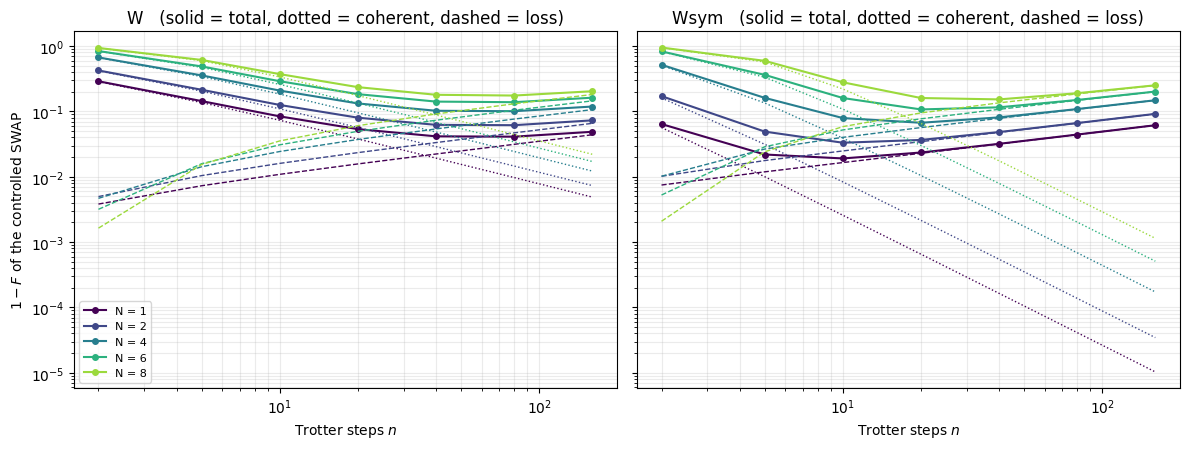

nsteps     eps  T (us)     1-F  coherent    loss
photons scheme                                                  
1       W           80 0.09908   4.137 0.04109  0.009727 0.03136
        Wsym        10  0.1982   2.119 0.01907  0.002576  0.0165
2       W           80 0.09908   4.137 0.06158   0.01459 0.04699
        Wsym        10  0.1982   2.119 0.03318  0.008339 0.02484
4       W           80 0.09908   4.137  0.1008   0.02436  0.0764
        Wsym        20  0.1401   2.955 0.06705   0.01045 0.05661
6       W           80 0.09908   4.137  0.1385    0.0342  0.1043
        Wsym        20  0.1401   2.955  0.1073   0.03018 0.07711
8       W           80 0.09908   4.137   0.175    0.0442  0.1308
        Wsym        40 0.09908   4.137  0.1528   0.01753  0.1353

The optimum trades a coherent error falling as 1/n^2 (Wsym) against a loss
penalty growing as sqrt(n), because the gate duration scales as sqrt(n).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
colors = plt.cm.viridis(np.linspace(0, 0.85, len(PHOTONS)))
for ax, name in zip(axes, ("W", "Wsym")):
    sub = scan[scan.scheme == name]
    for c, N in zip(colors, PHOTONS):
        d = sub[sub.photons == N]
        ax.loglog(d.nsteps, d["1-F"], "o-", color=c, ms=4, label=f"N = {N}")
        ax.loglog(d.nsteps, d.coherent, ":", color=c, lw=1)
        ax.loglog(d.nsteps, d.loss, "--", color=c, lw=1)
    ax.set_xlabel("Trotter steps $n$")
    ax.set_title(f"{name}   (solid = total, dotted = coherent, dashed = loss)")
    ax.grid(True, which="both", alpha=0.25)
axes[0].set_ylabel(r"$1-F$ of the controlled SWAP")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

best = (scan.loc[scan.groupby(["photons", "scheme"])["1-F"].idxmin()]
        .set_index(["photons", "scheme"])
        [["nsteps", "eps", "T (us)", "1-F", "coherent", "loss"]])
display(best)
print("The optimum trades a coherent error falling as 1/n^2 (Wsym) against a loss")
print("penalty growing as sqrt(n), because the gate duration scales as sqrt(n).")

### 6a. The rigorous number: average gate fidelity at the optimum

In [8]:
def avg_fid_open(s, segs, N):
    """Exact average gate fidelity from the Lindblad channel.

    F_e = (1/d^2) sum_mn <u_m| E(|i_m><i_n|) |u_n>,  |u_m> = U_CSWAP |i_m>.
    All d^2 basis matrices are stacked into ONE block and propagated together.
    """
    logical = logical_sector(s, N)
    d = len(logical)
    block = np.zeros((s.D * s.D, d * d), dtype=complex)
    for m, i in enumerate(logical):                     # row index of |i_m>
        for n, j in enumerate(logical):                 # column index of <i_n|
            block[j * s.D + i, m * d + n] = 1.0         # vec(|i_m><i_n|)
    out = evolve(s, segs, block)                        # one call, d^2 columns
    U = cswap_target(s)[:, logical]                     # the |u_m>
    F_e = 0.0j
    for m in range(d):
        for n in range(d):
            F_e += U[:, m].conj() @ unvec(out[:, m * d + n], s.D) @ U[:, n]
    F_e = float(np.real(F_e)) / d ** 2
    return (d * F_e + 1) / (d + 1)


t0 = time.time()
PHOTONS_EXACT = (1, 2, 4, 8)          # d^2 propagations: the N = 8 runs dominate
rows = []
for N in PHOTONS_EXACT:
    s = links[N]
    n_hat = int(best.loc[(N, "Wsym"), "nsteps"])        # optimum from the state test
    grid = [n for n in NSTEPS if n_hat / 2.5 <= n <= n_hat * 1.1]      # bracket it
    for n in grid:
        segs, eps = cswap_pulses(s, "Wsym", n)
        full = 1 - avg_fid_open(s, segs, N)
        state = scan[(scan.photons == N) & (scan.scheme == "Wsym")
                     & (scan.nsteps == n)]["1-F"].iloc[0]
        rows.append({"photons": N, "d = 2(N+1)": 2 * (N + 1), "nsteps": n,
                     "T (us)": sum(dt for _, _, dt in segs), "1-F_avg": full,
                     "coherent": 1 - avg_fid_closed(s, "Wsym", n, N),
                     "1-F state test": float(state)})
        print(f"  N = {N}, n = {n} done  [{time.time()-t0:.0f} s]")
df_avg = pd.DataFrame(rows).set_index(["photons", "nsteps"])
df_avg["loss"] = df_avg["1-F_avg"] - df_avg["coherent"]
df_avg["state test / exact"] = df_avg["1-F state test"] / df_avg["1-F_avg"]
display(df_avg[["d = 2(N+1)", "T (us)", "1-F_avg", "coherent", "loss",
                "1-F state test", "state test / exact"]])
print("The state test reproduces the SHAPE of the optimum (same best n) but")
print("UNDERSTATES the average gate infidelity, increasingly so at high photon number:")
print("it probes only the input |N,0>, whereas the average also covers |k,N-k> inputs")
print("that expose both cavities to loss at once.  Quote the 1-F_avg column.")
print(f"[{time.time()-t0:.1f} s]")

  N = 1, n = 5 done  [0 s]
  N = 1, n = 10 done  [0 s]


  N = 2, n = 5 done  [0 s]


  N = 2, n = 10 done  [1 s]


  N = 4, n = 10 done  [3 s]


  N = 4, n = 20 done  [6 s]


  N = 8, n = 20 done  [126 s]


  N = 8, n = 40 done  [334 s]


d = 2(N+1)  T (us)  1-F_avg  coherent    loss  1-F state test  \
photons nsteps                                                                  
1       5                4   1.527  0.01877  0.008013 0.01076         0.02191   
        10               4   2.119  0.01703   0.00206 0.01497         0.01907   
2       5                6   1.527  0.05693   0.03965 0.01728         0.04909   
        10               6   2.119  0.03526    0.0106 0.02466         0.03318   
4       10              10   2.119     0.12   0.07527 0.04473         0.07915   
        20              10   2.955  0.08611   0.02065 0.06546         0.06705   
8       20              18   2.955   0.3122    0.1931  0.1191          0.1604   
        40              18   4.137   0.2424   0.05499  0.1874          0.1528   

                state test / exact  
photons nsteps                      
1       5                    1.168  
        10                    1.12  
2       5                   0.8623  
        10                   0.941  
4       10                  0.6596  
        20                  0.7787  
8       20                  0.5139  
        40                  0.6305

The state test reproduces the SHAPE of the optimum (same best n) but
UNDERSTATES the average gate infidelity, increasingly so at high photon number:
it probes only the input |N,0>, whereas the average also covers |k,N-k> inputs
that expose both cavities to loss at once.  Quote the 1-F_avg column.
[334.0 s]


### 6b. Which decoherence channel dominates?

Photon loss costs $\propto N$, but cavity dephasing acts through $n_a$ and $n_b$ and could
in principle dephase $|N,0\rangle$ against $|0,N\rangle$ at a rate $\propto N^2$ — so which
one wins by eight photons is a quantitative question.  Running the exact channel with one
collapse operator at a time, and subtracting the coherent baseline, answers it: **cavity
loss dominates throughout**, by roughly $5\times$ over the cavity-dephasing and transmon
terms even at $N=8$.  The $N^2$ growth never gets the chance to take over, because the
optimum shifts to larger $n$ (longer gates) as $N$ rises, and both effects are cut short
by the same duration.

,coherent,cavity a loss,cavity b loss,cavity a dephasing,cavity b dephasing,transmon decay,transmon dephasing,sum of parts,total
photons,,,,,,,,,
1,0.002576,0.005687,0.001372,0.0006424,0.0005876,0.003935,0.004382,0.01918,0.01907
2,0.008339,0.01127,0.002663,0.001292,0.001182,0.004314,0.004358,0.03342,0.03318
4,0.01045,0.03114,0.007247,0.003485,0.003332,0.00647,0.006053,0.06817,0.06705
6,0.03018,0.04552,0.0105,0.005383,0.00516,0.006665,0.005924,0.1093,0.1073
8,0.01753,0.0844,0.01975,0.009829,0.009617,0.009463,0.008392,0.159,0.1528


`sum of parts` vs `total` shows how well the channels act independently;
the gap is the cross term between simultaneously acting decoherence channels.


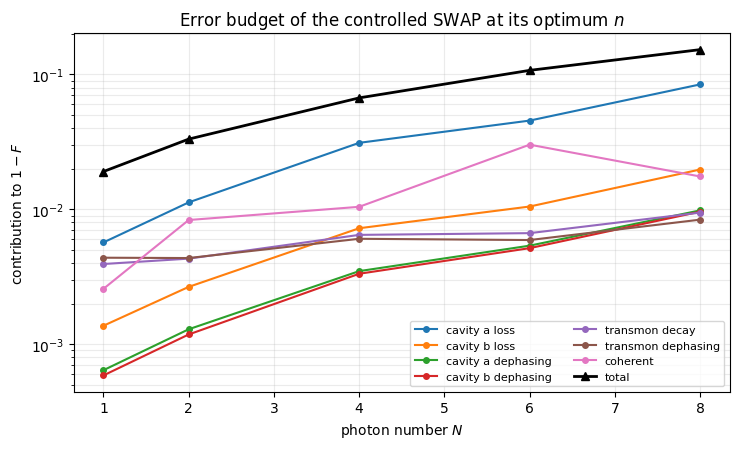

Cavity a dominates because the test state starts with all N photons there;
for the average gate fidelity the two cavities enter symmetrically.


In [9]:
rows = []
for N in PHOTONS:
    s = links[N]
    n = int(best.loc[(N, "Wsym"), "nsteps"])            # the optimum for this N
    segs, _ = cswap_pulses(s, "Wsym", n)
    coh = state_infidelity(s, segs, N, channels=())     # closed-system baseline
    row = {"photons": N, "coherent": coh, "total": state_infidelity(s, segs, N)}
    # each channel's MARGINAL cost: run it alone, then subtract the coherent baseline
    for k, name in enumerate(s.c_names):
        row[name] = state_infidelity(s, segs, N, channels=(k,)) - coh
    rows.append(row)
budget = pd.DataFrame(rows).set_index("photons")
CHANNELS = list(links[1].c_names)
budget["sum of parts"] = budget["coherent"] + budget[CHANNELS].sum(axis=1)
display(budget[["coherent"] + CHANNELS + ["sum of parts", "total"]])
print("`sum of parts` vs `total` shows how well the channels act independently;")
print("the gap is the cross term between simultaneously acting decoherence channels.")

fig, ax = plt.subplots(figsize=(7.5, 4.6))
for col in CHANNELS + ["coherent"]:
    ax.plot(budget.index, budget[col], "o-", ms=4, label=col)
ax.plot(budget.index, budget["total"], "k^-", ms=6, lw=2, label="total")
ax.set_yscale("log")
ax.set_xlabel("photon number $N$")
ax.set_ylabel(r"contribution to $1-F$")
ax.set_title("Error budget of the controlled SWAP at its optimum $n$")
ax.legend(fontsize=8, ncol=2)
ax.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.show()
print("Cavity a dominates because the test state starts with all N photons there;")
print("for the average gate fidelity the two cavities enter symmetrically.")

# Part II — the same construction on a chain

Three transmons and four cavities, $q_j$ controlling the link $C_j\!-\!C_{j+1}$:

$$H/\hbar = J\sum_{j=1}^{3}\sigma^z_j\left(a_j^\dagger a_{j+1}+a_ja_{j+1}^\dagger\right).$$

Each $q_j$ has an $A$ leg to $C_j$ and a $B$ leg to $C_{j+1}$.  The natural schedule is to
fire all three $A$ sidebands at once, then all three $B$ sidebands at once.  This part is
**coherent only** — the chain's Liouvillian has $2048^2$ entries, far beyond exact
treatment, and Part I already establishes the loss scale.

Two questions: can the sidebands fire in parallel, and does the group commutator still
give what we want?

In [10]:
NQ, NCAV = 3, 4


class Chain:
    """3 transmons (g,e) x 4 cavities, tensor ordering [q1 q2 q3 C1 C2 C3 C4].

    Built with qt.expand_operator, so every operator is a one-liner.  The propagator
    never exponentiates a D x D matrix: each sideband acts on ONE (transmon, cavity)
    pair, so its 2-site exponential is embedded and applied as a sparse matrix.
    """

    def __init__(self, nc=4, n_log=1):
        self.nc, self.n_log = nc, n_log
        self.dims = [2] * NQ + [nc] * NCAV
        self.D = int(np.prod(self.dims))
        g2, e2 = qt.basis(2, 0), qt.basis(2, 1)

        def emb(op, targets):
            """Embed a small operator into the chain at the given tensor slots."""
            return qt.expand_operator(op, dims=self.dims, targets=targets)

        self.emb = emb
        self.sp = [emb(e2 * g2.dag(), [j]) for j in range(NQ)]         # sigma_+ per qubit
        self.sm = [o.dag() for o in self.sp]
        self.sx = [p + m for p, m in zip(self.sp, self.sm)]
        self.sz = [emb(g2 * g2.dag() - e2 * e2.dag(), [j]) for j in range(NQ)]
        self.a = [emb(qt.destroy(nc), [NQ + k]) for k in range(NCAV)]  # one per cavity
        self.identity = emb(qt.qeye(2), [0])
        self.X = [self.a[k].dag() * self.a[k + 1] + self.a[k] * self.a[k + 1].dag()
                  for k in range(NCAV - 1)]                            # X on each link
        self.H_target = sum(self.sz[j] * self.X[j] for j in range(NQ))

        # link j: A leg on (q_j, C_j) at phi = pi/2, B leg on (q_j, C_{j+1}) at psi = 0
        self.HA = [G * (1j * self.a[j] * self.sp[j]
                        - 1j * self.a[j].dag() * self.sm[j]) for j in range(NQ)]
        self.HB = [G * (self.a[j + 1] * self.sp[j]
                        + self.a[j + 1].dag() * self.sm[j]) for j in range(NQ)]

        # the same two Hamiltonians as 2-site (qubit x cavity) operators
        sp2, a2 = e2 * g2.dag(), qt.destroy(nc)
        jc = qt.tensor(sp2, a2)                                        # sigma_+ a
        self.h2 = {"A": G * (1j * jc - 1j * jc.dag()), "B": G * (jc + jc.dag())}
        self.slots = {("A", j): [j, NQ + j] for j in range(NQ)}
        self.slots.update({("B", j): [j, NQ + j + 1] for j in range(NQ)})

        self.logical = self._logical()
        self.d = len(self.logical)
        self._pulse_cache, self._target_cache = {}, {}

    def _logical(self):
        """Rows of |q1q2q3; n1..n4> with total photons <= n_log: the logical subspace."""
        stride = np.cumprod([1] + self.dims[::-1])[:-1][::-1]          # index strides
        idx = []
        for bits in itertools.product((0, 1), repeat=NQ):              # all qubit states
            for ns in itertools.product(range(self.nc), repeat=NCAV):   # all Fock states
                if sum(ns) <= self.n_log:
                    idx.append(int(np.dot(stride, list(bits) + list(ns))))
        return np.asarray(sorted(idx), dtype=int)

    def cols(self):
        """The logical subspace as a D x d matrix of basis columns."""
        E = np.zeros((self.D, self.d), dtype=complex)
        E[self.logical, np.arange(self.d)] = 1.0
        return E

    def sparse(self, op):
        """The scipy CSR matrix behind a Qobj."""
        return op.to("csr").data_as("csr_matrix")

    def target_cols(self, theta):
        """exp(-i theta H_target) acting on the logical columns, cached."""
        if theta not in self._target_cache:
            self._target_cache[theta] = expm_multiply(
                -1j * theta * self.sparse(self.H_target), self.cols())
        return self._target_cache[theta]

    def pulse(self, leg, j, coeff, tau):
        """exp(-i coeff h2 tau) for leg 'A'/'B' of link j, embedded and sparse, cached."""
        key = (leg, j, round(coeff, 12), round(tau, 13))
        if key not in self._pulse_cache:
            u2 = (-1j * coeff * tau * self.h2[leg]).expm()             # 2-site, tiny
            self._pulse_cache[key] = self.sparse(self.emb(u2, self.slots[(leg, j)]))
        return self._pulse_cache[key]


ch = Chain(nc=4, n_log=1)
print(f"D = {ch.D}, logical dimension d = {ch.d}")

sim = {}
for j, k in itertools.combinations(range(NQ), 2):        # every pair of links
    sim[f"[A_{j+1}, A_{k+1}]"] = mx(comm(ch.HA[j], ch.HA[k]))
    sim[f"[B_{j+1}, B_{k+1}]"] = mx(comm(ch.HB[j], ch.HB[k]))
tau = 0.037
for tag, H in (("A", ch.HA), ("B", ch.HB)):              # simultaneous vs sequential
    full = (-1j * sum(H) * tau).expm()
    prod = (-1j * H[0] * tau).expm() * (-1j * H[1] * tau).expm() * (-1j * H[2] * tau).expm()
    sim[f"exp(-i tau sum_j {tag}_j) - prod_j exp(-i tau {tag}_j)"] = mx(full - prod)
display(pd.Series(sim, name="residual").to_frame())
assert max(sim.values()) < 1e-12
print("Each group acts on DISJOINT (transmon, cavity) pairs, so the three sidebands")
print("commute exactly: one simultaneous pulse, with no splitting error at any order.")

D = 2048, logical dimension d = 40


,residual
"[A_1, A_2]",0
"[B_1, B_2]",0
"[A_1, A_3]",0
"[B_1, B_3]",0
"[A_2, A_3]",0
"[B_2, B_3]",0
exp(-i tau sum_j A_j) - prod_j exp(-i tau A_j),4.441e-16
exp(-i tau sum_j B_j) - prod_j exp(-i tau B_j),4.441e-16


Each group acts on DISJOINT (transmon, cavity) pairs, so the three sidebands
commute exactly: one simultaneous pulse, with no splitting error at any order.


## 7. The cross-group commutator picks up a spurious term

With $A=\sum_jA_j$ and $B=\sum_jB_j$ the step generator is $i[A,B]$, which has nine
terms.  $[A_i,B_k]$ is nonzero only when the two share a tensor factor:

* $i=k$ — they share the **transmon** $q_i$: this is the wanted $\sigma^z_iX_i$;
* $i=k+1$ — $A_{k+1}$ lives on $(q_{k+1},C_{k+1})$ and $B_k$ on $(q_k,C_{k+1})$, so they
  share the **cavity** $C_{k+1}$: this is spurious.

For the spurious pair, $S_1$ and $S_2$ act on different transmons and commute, so
$[PS_2,QS_1]=[P,Q]S_1S_2$ and only the $[a,a^\dagger]=1$ pairings survive:

$$i\,\frac{[A_{k+1},B_k]}{g^2}
=-\left(\sigma^+_{k+1}\sigma^-_{k}+\sigma^-_{k+1}\sigma^+_{k}\right),$$

an **$XY$ exchange between neighbouring transmons**, with the photon operators dropping
out entirely.  Its coefficient is $1$ against the signal's — it is not a perturbative
correction, it is half the generator — and being photon-independent it does not vanish in
the low-photon sector.

Its fingerprint is unmistakable: with **all cavities in vacuum**, where $H_{\rm target}$
annihilates the state and a perfect step is the identity, it still flips
$|egg\rangle\leftrightarrow|geg\rangle$.

No choice of pump phase removes it — $e^{i\delta}\sigma^+\sigma^--\mathrm{h.c.}$ is nonzero
for every $\delta$.  But an **alternating sign** does.  Attaching $s_j=\pm1$ to both pumps
of link $j$ (free: $A_{\phi+\pi}=-A_\phi$),

$$[s_jA_j,s_jB_j]=[A_j,B_j],\qquad
[s_{k+1}A_{k+1},s_kB_k]=s_ks_{k+1}[A_{k+1},B_k],$$

so running the unit once with $s=(+,+,+)$ and once with $s=(+,-,+)$ leaves every wanted
term alone and flips every spurious one.  They cancel, and the two blocks *add* their
angles.  For a longer chain take $s_j=(-1)^j$.

The alternative is the textbook **odd/even split** — links 1 and 3 in one block (they
share no cavity), link 2 in another.  It also works, but it is $\sqrt2$ longer and about
twice as inaccurate at the same output angle, because it cannot drive all three links at
once.

In [11]:
SPLUS, SMINUS = (+1, +1, +1), (+1, -1, +1)      # only q2's two pumps shift by pi
ALL, LINKS13, LINK2 = (1, 1, 1), (1, 0, 1), (0, 1, 0)


def generator(ch, mask, signs):
    """i[A, B]/g^2 for the selected links and pump signs -- the step's generator."""
    A = sum(m * sg * h for m, sg, h in zip(mask, signs, ch.HA))
    B = sum(m * sg * h for m, sg, h in zip(mask, signs, ch.HB))
    return 1j * comm(A, B) / G ** 2


# [a, a^dag] = 1 only away from the top Fock state, so compare inside the safe sector
safe = ch.identity
for k in range(NCAV):
    top = qt.basis(ch.nc, ch.nc - 1) * qt.basis(ch.nc, ch.nc - 1).dag()
    safe = safe * (ch.identity - ch.emb(top, [NQ + k]))
mxs = lambda op: mx(safe * op * safe)

# the spurious term, written out: an XY exchange between NEIGHBOURING transmons
H_spur = -sum(ch.sp[j] * ch.sm[j - 1] + ch.sm[j] * ch.sp[j - 1] for j in (1, 2))

rows = []
for j, k in itertools.product(range(NQ), range(NQ)):     # all nine cross terms
    C = 1j * comm(ch.HA[j], ch.HB[k]) / G ** 2
    kind = ("0  (disjoint)" if mx(C) < 1e-13 else
            f"WANTED  sz_{j+1} X_{j+1}" if j == k else
            f"SPURIOUS  XY(q{k+1},q{j+1})")
    rows.append({"term": f"i[A_{j+1}, B_{k+1}]/g^2", "A on": f"(q{j+1},C{j+1})",
                 "B on": f"(q{k+1},C{k+2})", "norm (safe sector)": mxs(C), "kind": kind})
display(pd.DataFrame(rows).set_index("term"))

exact = {
    "generator, s = (+,+,+)   minus (H_target + H_spur)":
        mxs(generator(ch, ALL, SPLUS) - ch.H_target - H_spur),
    "generator, s = (+,-,+)   minus (H_target - H_spur)":
        mxs(generator(ch, ALL, SMINUS) - ch.H_target + H_spur),
    "staggered echo: SUM of the two blocks minus 2 H_target":
        mxs(generator(ch, ALL, SPLUS) + generator(ch, ALL, SMINUS) - 2 * ch.H_target),
    "odd/even split: links 1,3 block minus (sz1 X1 + sz3 X3)":
        mxs(generator(ch, LINKS13, SPLUS) - ch.sz[0] * ch.X[0] - ch.sz[2] * ch.X[2]),
    "odd/even split: link 2 block minus sz2 X2":
        mxs(generator(ch, LINK2, SPLUS) - ch.sz[1] * ch.X[1]),
}
display(pd.Series(exact, name="residual").to_frame())
assert max(exact.values()) < 1e-12
print("Both mitigations are exact at the level of the leading generator.\n")

# Gauss operator at matter site C2:  (-1)^{n_2} sx_1 sx_2  (both links touch C2)
parity2 = (1j * np.pi * ch.a[1].dag() * ch.a[1]).expm()
G_C2 = parity2 * ch.sx[0] * ch.sx[1]
sizes = {"||H_target|| (safe sector)": mxs(ch.H_target),
         "||H_spur||   (safe sector, same order as the signal)": mxs(H_spur),
         "[G_C2, H_target]  (the target is gauge invariant)": mx(comm(G_C2, ch.H_target)),
         "[G_C2, H_spur]    (the spurious term is NOT)": mx(comm(G_C2, H_spur))}
display(pd.Series(sizes, name="value").to_frame())

,A on,B on,norm (safe sector),kind
term,,,,
"i[A_1, B_1]/g^2","(q1,C1)","(q1,C2)",2,WANTED sz_1 X_1
"i[A_1, B_2]/g^2","(q1,C1)","(q2,C3)",0,0 (disjoint)
"i[A_1, B_3]/g^2","(q1,C1)","(q3,C4)",0,0 (disjoint)
"i[A_2, B_1]/g^2","(q2,C2)","(q1,C2)",1,"SPURIOUS XY(q1,q2)"
"i[A_2, B_2]/g^2","(q2,C2)","(q2,C3)",2,WANTED sz_2 X_2
"i[A_2, B_3]/g^2","(q2,C2)","(q3,C4)",0,0 (disjoint)
"i[A_3, B_1]/g^2","(q3,C3)","(q1,C2)",0,0 (disjoint)
"i[A_3, B_2]/g^2","(q3,C3)","(q2,C3)",1,"SPURIOUS XY(q2,q3)"
"i[A_3, B_3]/g^2","(q3,C3)","(q3,C4)",2,WANTED sz_3 X_3


,residual
"generator, s = (+,+,+) minus (H_target + H_spur)",0
"generator, s = (+,-,+) minus (H_target - H_spur)",0
staggered echo: SUM of the two blocks minus 2 H_target,0
"odd/even split: links 1,3 block minus (sz1 X1 + sz3 X3)",0
odd/even split: link 2 block minus sz2 X2,0


Both mitigations are exact at the level of the leading generator.



,value
||H_target|| (safe sector),2
"||H_spur|| (safe sector, same order as the signal)",1
"[G_C2, H_target] (the target is gauge invariant)",8.361e-15
"[G_C2, H_spur] (the spurious term is NOT)",1


pulses  T (ns)       1-F  P(egg->geg) in vacuum
theta scheme                                                   
0.05  naive          4   113.9  0.002806               0.002186
      echo           8   161.1 0.0002381               8.92e-15
      echosym       16   227.8 2.709e-06              1.452e-11
      split          8   227.8 0.0004039              8.398e-10
      splitsym      16   322.1 6.201e-06              6.194e-18
0.1   naive          4   161.1   0.01248               0.007631
      echo           8   227.8  0.001835              2.135e-12
      echosym       16   322.1 4.244e-05              8.844e-10
      split          8   322.1  0.003095              4.613e-08
      splitsym      16   455.5 9.744e-05              6.549e-15
0.2   naive          4   227.8   0.05725                0.02312
      echo           8   322.1   0.01356              4.777e-10
      echosym       16   455.5 0.0006496              5.131e-08
      split          8   455.5   0.02248              2.162e-06
      splitsym      16   644.2  0.001493              7.031e-12

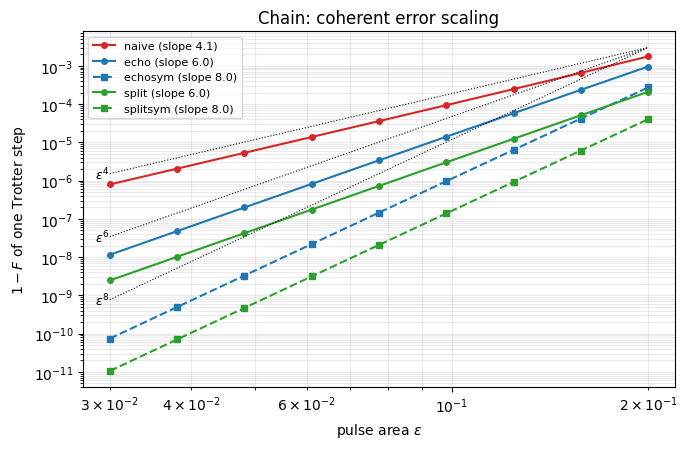

naive is stuck at eps^4 -- the spurious term is the same order as the signal.
The staggered echo restores eps^6, and with symmetrization eps^8.


In [12]:
def chain_leg(mask, signs, eps):
    """One 4-pulse group commutator on the chain, in time order.

    Each entry is (leg, {link: pump sign}, duration): all the links in the dict fire
    SIMULTANEOUSLY, which the cell above proved is exact.
    """
    tau = abs(eps) / G                                   # eps = g tau
    e = 1.0 if eps >= 0 else -1.0                        # overall sign of the group
    active = {j: sg for j, (m, sg) in enumerate(zip(mask, signs)) if m}
    return [("B", {j: -e * v for j, v in active.items()}, tau),
            ("A", {j: -e * v for j, v in active.items()}, tau),
            ("B", {j: +e * v for j, v in active.items()}, tau),
            ("A", {j: +e * v for j, v in active.items()}, tau)]


def chain_sym(mask, signs, eps):
    """Wsym on the chain: W(-eps) first, then W(+eps)."""
    return chain_leg(mask, signs, -eps) + chain_leg(mask, signs, eps)


# (builder, f) with theta = -f eps^2 for each mitigation strategy
CHAIN_SCHEMES = {
    "naive":    (lambda e: chain_leg(ALL, SPLUS, e), 1),
    "echo":     (lambda e: chain_leg(ALL, SPLUS, e) + chain_leg(ALL, SMINUS, e), 2),
    "echosym":  (lambda e: chain_sym(ALL, SPLUS, e) + chain_sym(ALL, SMINUS, e), 4),
    "split":    (lambda e: chain_leg(LINKS13, SPLUS, e) + chain_leg(LINK2, SPLUS, e), 1),
    "splitsym": (lambda e: chain_sym(LINKS13, SPLUS, e) + chain_sym(LINK2, SPLUS, e), 2),
}


def chain_propagate(ch, segs, E):
    """Propagate the logical columns E through the pulse list, one 2-site factor at a
    time -- so a 2048-dimensional exponential is never formed."""
    for leg, coeffs, tau in segs:
        for j, sign in coeffs.items():                   # simultaneous, so order is free
            E = ch.pulse(leg, j, sign, tau) @ E
    return E


def chain_fidelity(U, T, d):
    """Average gate fidelity from the propagated logical columns."""
    F_e = abs(np.trace(T.conj().T @ U)) ** 2 / d ** 2
    return float((d * F_e + 1) / (d + 1))


E0 = ch.cols()
stride = np.cumprod([1] + ch.dims[::-1])[:-1][::-1]
row_of = lambda bits, ns: int(np.dot(stride, list(bits) + list(ns)))
col_of = {row: col for col, row in enumerate(ch.logical)}
VAC = (0, 0, 0, 0)                                       # all cavities empty

rows = []
for theta in (0.05, 0.10, 0.20):
    for name, (build, f) in CHAIN_SCHEMES.items():
        eps = np.sqrt(theta / f)                         # theta = f eps^2
        segs = build(eps)
        U = chain_propagate(ch, segs, E0)
        # the spurious term's fingerprint: |egg> -> |geg| with every cavity empty
        flip = abs(U[row_of([0, 1, 0], VAC), col_of[row_of([1, 0, 0], VAC)]]) ** 2
        rows.append({"theta": theta, "scheme": name, "pulses": len(segs),
                     "T (ns)": 1e3 * sum(t for _, _, t in segs),
                     "1-F": 1 - chain_fidelity(U, ch.target_cols(-theta), ch.d),
                     "P(egg->geg) in vacuum": flip})
display(pd.DataFrame(rows).set_index(["theta", "scheme"]))

eps_grid = np.geomspace(0.03, 0.20, 9)
scal = {}
for name, (build, f) in CHAIN_SCHEMES.items():
    errs = []
    for eps in eps_grid:
        U = chain_propagate(ch, build(eps), E0)
        errs.append(1 - chain_fidelity(U, ch.target_cols(-f * eps ** 2), ch.d))
    scal[name] = np.array(errs)
slopes = {n: np.polyfit(np.log(eps_grid), np.log(v), 1)[0] for n, v in scal.items()}

fig, ax = plt.subplots(figsize=(7, 4.6))
sty = {"naive": ("o-", "tab:red"), "echo": ("o-", "tab:blue"),
       "echosym": ("s--", "tab:blue"), "split": ("o-", "tab:green"),
       "splitsym": ("s--", "tab:green")}
for name, v in scal.items():
    marker, colour = sty[name]
    ax.loglog(eps_grid, v, marker, color=colour, ms=4,
              label=f"{name} (slope {slopes[name]:.1f})")
for p, lab in ((4, r"$\epsilon^4$"), (6, r"$\epsilon^6$"), (8, r"$\epsilon^8$")):
    guide = 3e-3 * (eps_grid / 0.2) ** p
    ax.loglog(eps_grid, guide, "k:", lw=0.8)
    ax.annotate(lab, (eps_grid[0], guide[0]), fontsize=9, ha="right", va="center")
ax.set_xlabel(r"pulse area $\epsilon$")
ax.set_ylabel(r"$1-F$ of one Trotter step")
ax.set_title("Chain: coherent error scaling")
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.show()

assert 3.7 < slopes["naive"] < 4.3          # limited by the spurious term
assert 5.7 < slopes["echo"] < 6.3 and 7.7 < slopes["echosym"] < 8.3
print("naive is stuck at eps^4 -- the spurious term is the same order as the signal.")
print("The staggered echo restores eps^6, and with symmetrization eps^8.")

## 8. Conclusions

**Part I — the controlled SWAP.**

1. $i[\bar A_{\pi/2},\bar B_0]=\sigma^z(a^\dagger b+ab^\dagger)$ holds exactly on the
   $g1e0$ ladder, with $\sigma^z=P_g-P_e$ the ordinary qubit $\sigma^z$.  No third level
   is involved anywhere.
2. $B(\pi/4)\,e^{+i\frac\pi4\sigma^zX_{ab}}$ **is** a controlled SWAP: identity on
   $|g\rangle$, $(-i)^{\hat N}S$ on $|e\rangle$.  The phase $(-i)^{\hat N}$ is global
   inside each photon sector.
3. Splitting $\pi/4$ into $n$ Trotter steps, the coherent error falls as $n^{-2}$ for
   $W_{\rm sym}$ while the duration grows as $\sqrt n$, giving a sharp optimum.
4. **At the optimum the gate is loss-limited, not Trotter-limited.**  With
   $T_1^{\rm cav}=300$ µs the exact average gate infidelity is $1.7\%$ at one photon,
   $8.6\%$ at four and $24\%$ at eight, because the gate takes microseconds and $N$
   photons decay $N$ times faster.  Cavity loss is the largest single contributor at
   every $N$, about $5\times$ the cavity-dephasing and transmon terms.
5. The way to improve this is a **larger $g$**, not a better sequence.  At the optimum the
   loss term is $3\!-\!4\times$ the coherent term, and the two cannot both be reduced by
   re-tuning $n$ — coherent error falls as $1/n^2$ exactly where loss grows as $\sqrt n$.
   Raising $g$ shortens the gate at fixed angle and fixed coherent error, moving the whole
   trade-off curve down.
6. **The cheap entangling state test is not a substitute for the average gate fidelity.**
   It finds the same optimum $n$, but understates the infidelity by up to $2\times$ at
   eight photons, because it probes only the $|N,0\rangle$ input.

**Part II — the chain.**

7. The three $A$ sidebands (and the three $B$ sidebands) act on disjoint
   (transmon, cavity) pairs, so each group fires as **one simultaneous pulse with exactly
   zero splitting error**.
8. But the shared cavities $C_2,C_3$ make the cross-group commutator produce a spurious
   **transmon–transmon $XY$ exchange** of the same order as the signal, photon-number
   independent, breaking Gauss's law, and visible as a neighbouring-transmon flip with
   all cavities in vacuum ($2.3\%$ per step at $\theta=0.2$).
9. A **staggered pump phase** — a $\pi$ shift on $q_2$'s two pumps in the second block,
   $s_j=(-1)^j$ in general — cancels it for free, restoring $\epsilon^6$ (and $\epsilon^8$
   with symmetrization).  This beats the odd/even split on both time and accuracy.

**What is not modelled.**  Frequency crowding (each transmon's two pumps are separated
only by $|\omega_{C_j}-\omega_{C_{j+1}}|$, which must be $\gg g/2\pi=1.25$ MHz),
pump-induced Stark shifts with several pumps on at once, and $n_{\rm th}$, which is set to
zero (worth $\sim10^{-4}$ here).  The native beamsplitter rate $g_{\rm BS}$ is taken equal
to $g$; it contributes one 100 ns pulse out of a multi-µs gate, so the results barely
depend on it.